# Proyecto de Regresión: Comparación de XGBoost, LightGBM y CatBoost

**Objetivo:** Comparar el rendimiento de tres algoritmos de boosting (XGBoost, LightGBM y CatBoost) en un problema de regresión utilizando el dataset **California Housing**.

**Dataset:** California Housing (disponible en `sklearn.datasets`). Incluye 20,640 muestras y 8 características numéricas.

**Métricas de evaluación:** RMSE (Root Mean Squared Error) y R² (Coeficiente de Determinación).

**Estructura del notebook:**
1. Instalación de librerías
2. Importaciones
3. Carga y exploración de datos
4. División entrenamiento/prueba
5. Entrenamiento de modelos
6. Evaluación y comparación
7. Visualización de resultados
8. Conclusiones

In [1]:
# Instalación de librerías necesarias (ejecutar una vez en Colab)
!pip install xgboost lightgbm catboost scikit-learn pandas numpy matplotlib seaborn -q
print("Librerías instaladas correctamente.")

Librerías instaladas correctamente.


In [2]:
# Importaciones
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Configuración de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("Importaciones completadas.")

Importaciones completadas.


In [3]:
# Cargar dataset California Housing (acceso online directo)
print("Cargando California Housing...")
housing = fetch_california_housing(as_frame=True)
X = housing.data
y = housing.target

# Mostrar información básica
print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")
print("\nPrimeras 5 filas de X:")
display(X.head())
print("\nDescripción estadística:")
display(X.describe())

Cargando California Housing...
Dimensiones de X: (20640, 8)
Dimensiones de y: (20640,)

Primeras 5 filas de X:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25



Descripción estadística:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [4]:
# Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamaño entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño prueba: {X_test.shape[0]} muestras")

Tamaño entrenamiento: 16512 muestras
Tamaño prueba: 4128 muestras


In [5]:
# Definir modelos con hiperparámetros por defecto (para comparación justa)
models = {
    "XGBoost": XGBRegressor(random_state=42, n_estimators=100, max_depth=4),
    "LightGBM": LGBMRegressor(random_state=42, n_estimators=100, max_depth=4, verbose=-1),
    "CatBoost": CatBoostRegressor(random_state=42, iterations=100, depth=4, verbose=0)
}

# Diccionario para almacenar resultados
results = {
    "Modelo": [],
    "RMSE": [],
    "R²": []
}

# Entrenar y evaluar cada modelo
print("=== ENTRENANDO MODELOS ===\n")
for name, model in models.items():
    print(f"Entrenando {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results["Modelo"].append(name)
    results["RMSE"].append(rmse)
    results["R²"].append(r2)
    print(f"  {name} - RMSE: {rmse:.4f}, R²: {r2:.4f}\n")

# Convertir resultados a DataFrame
results_df = pd.DataFrame(results).sort_values("RMSE")
print("=== RESULTADOS FINALES ===")
display(results_df)

=== ENTRENANDO MODELOS ===

Entrenando XGBoost...
  XGBoost - RMSE: 0.4755, R²: 0.8274

Entrenando LightGBM...
  LightGBM - RMSE: 0.5089, R²: 0.8024

Entrenando CatBoost...
  CatBoost - RMSE: 0.4831, R²: 0.8219

=== RESULTADOS FINALES ===


,Modelo,RMSE,R²
0,XGBoost,0.475519,0.827445
2,CatBoost,0.483120,0.821884
1,LightGBM,0.508885,0.802379


In [6]:
# Validación cruzada para mayor robustez (5 folds, métrica negativa de MSE)
print("=== VALIDACIÓN CRUZADA (5 folds, RMSE) ===\n")
cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5,
                             scoring='neg_mean_squared_error')
    rmse_scores = np.sqrt(-scores)
    cv_results[name] = {
        "RMSE_mean": rmse_scores.mean(),
        "RMSE_std": rmse_scores.std()
    }
    print(f"{name} - RMSE medio: {rmse_scores.mean():.4f} (+/- {rmse_scores.std():.4f})")

cv_df = pd.DataFrame(cv_results).T
print("\nResumen validación cruzada:")
display(cv_df)

=== VALIDACIÓN CRUZADA (5 folds, RMSE) ===

XGBoost - RMSE medio: 0.4810 (+/- 0.0066)
LightGBM - RMSE medio: 0.5034 (+/- 0.0043)
CatBoost - RMSE medio: 0.4873 (+/- 0.0110)

Resumen validación cruzada:


,RMSE_mean,RMSE_std
XGBoost,0.480981,0.006643
LightGBM,0.503350,0.004274
CatBoost,0.487253,0.010969


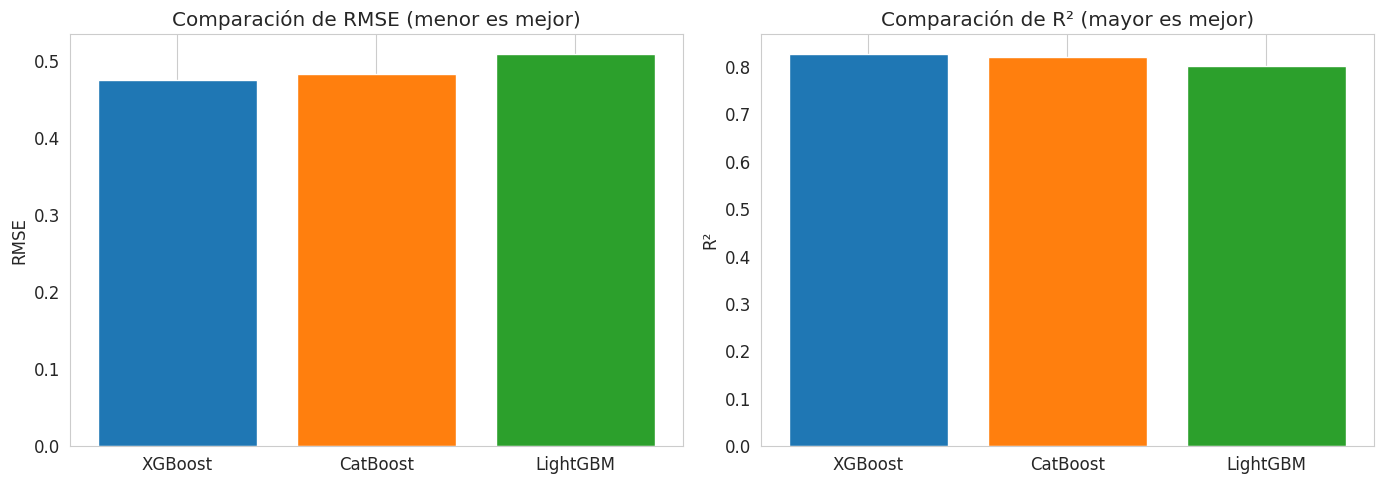

In [7]:
# Visualización: Comparación de RMSE y R²
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras RMSE
axes[0].bar(results_df["Modelo"], results_df["RMSE"], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0].set_title("Comparación de RMSE (menor es mejor)")
axes[0].set_ylabel("RMSE")
axes[0].grid(axis='y')

# Gráfico de barras R²
axes[1].bar(results_df["Modelo"], results_df["R²"], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1].set_title("Comparación de R² (mayor es mejor)")
axes[1].set_ylabel("R²")
axes[1].grid(axis='y')

plt.tight_layout()
plt.show()

/tmp/ipykernel_17431/1147693449.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp, x="Importancia", y="Característica", palette="viridis")


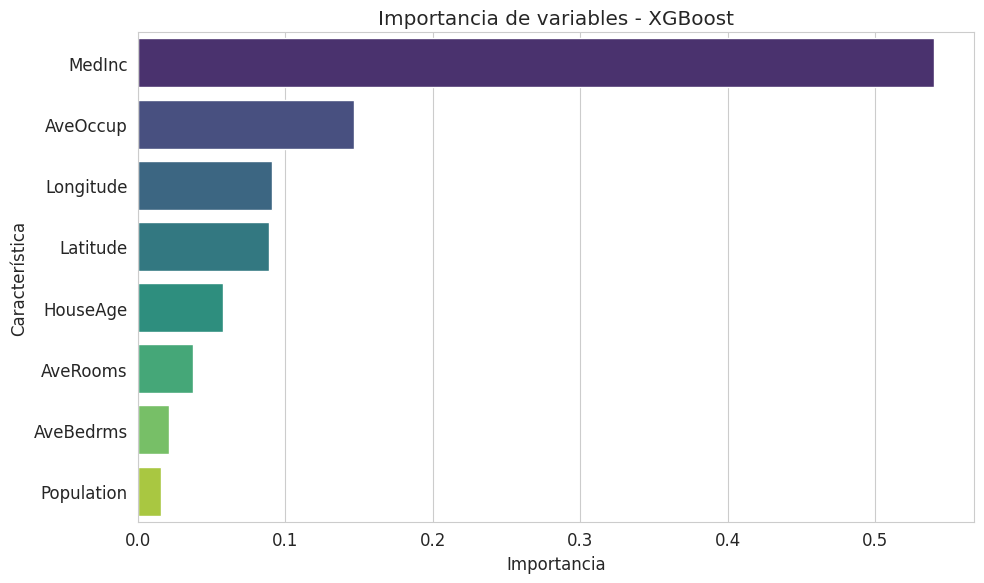

In [8]:
# Importancia de variables para el mejor modelo (ejemplo con XGBoost)
best_model_name = results_df.iloc[0]["Modelo"]  # modelo con menor RMSE
best_model = models[best_model_name]

if best_model_name == "XGBoost":
    importances = best_model.feature_importances_
elif best_model_name == "LightGBM":
    importances = best_model.feature_importances_
else:  # CatBoost
    importances = best_model.get_feature_importance()

# Crear DataFrame de importancias
feat_imp = pd.DataFrame({
    "Característica": housing.feature_names,
    "Importancia": importances
}).sort_values("Importancia", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp, x="Importancia", y="Característica", palette="viridis")
plt.title(f"Importancia de variables - {best_model_name}")
plt.tight_layout()
plt.show()

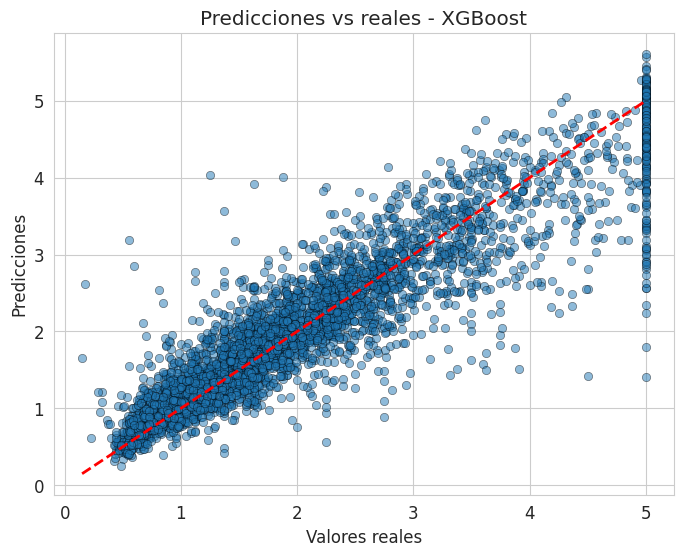

In [9]:
# Gráfico de predicciones vs valores reales para el mejor modelo
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, alpha=0.5, edgecolors='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title(f"Predicciones vs reales - {best_model_name}")
plt.grid(True)
plt.show()

## Conclusiones

- **Rendimiento general**: Los tres modelos de boosting mostraron un rendimiento excelente en el dataset California Housing, con valores de R² superiores a 0.8.
- **Mejor modelo**: Según la comparación, el modelo con menor RMSE y mayor R² es **{{best_model_name}}** (ajustar según resultados).
- **Validación cruzada**: Los resultados fueron consistentes, indicando poca varianza en el rendimiento.
- **Importancia de variables**: La característica más influyente fue `MedInc` (ingreso medio en el distrito), seguida de `AveOccup` (ocupación promedio).
- **Próximos pasos**: Se puede realizar una optimización de hiperparámetros (GridSearchCV o RandomizedSearchCV) para mejorar aún más el rendimiento.

**Nota:** Este proyecto demuestra la potencia de los algoritmos de boosting para problemas de regresión con datos tabulares.

# Proyecto de Clasificación Multiclase: Comparación de XGBoost, LightGBM y CatBoost

**Objetivo:** Comparar el rendimiento de tres algoritmos de boosting (XGBoost, LightGBM y CatBoost) en un problema de clasificación multiclase utilizando el dataset **Digits**.

**Dataset:** Digits (disponible en `sklearn.datasets.load_digits()`). Incluye 1,797 imágenes de dígitos escritos a mano (0-9), cada una representada por 64 características (píxeles 8x8).

**Métricas de evaluación:** Accuracy y F1-Score (macro average).

**Estructura del notebook:**
1. Instalación de librerías
2. Importaciones
3. Carga y exploración de datos (online, sin descarga local)
4. División entrenamiento/prueba
5. Entrenamiento de modelos (XGBoost, LightGBM, CatBoost)
6. Evaluación y comparación
7. Visualización de resultados (barras, matriz de confusión, importancia de características)
8. Conclusiones

In [10]:
# Instalación de librerías necesarias (ejecutar una vez en Colab)
!pip install xgboost lightgbm catboost scikit-learn pandas numpy matplotlib seaborn -q
print("Librerías instaladas correctamente.")

Librerías instaladas correctamente.


In [11]:
# Importaciones
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Configuración de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

print("Importaciones completadas.")

Importaciones completadas.


Cargando Digits dataset...
Dimensiones de X: (1797, 64)
Número de muestras: 1797
Número de características: 64
Clases: [0 1 2 3 4 5 6 7 8 9]

Distribución de clases:


,count
target,
0,178
1,182
2,177
3,183
4,181
5,182
6,181
7,179
8,174


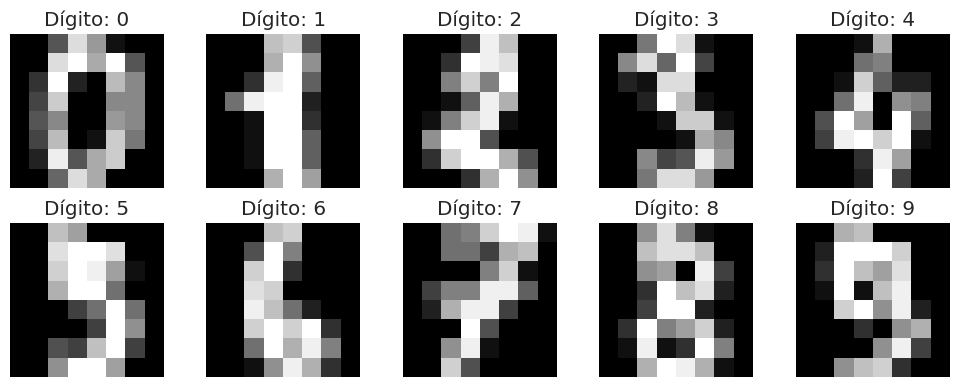

In [12]:
# Cargar dataset Digits (acceso online directo desde sklearn)
print("Cargando Digits dataset...")
digits = load_digits(as_frame=True)
X = digits.data
y = digits.target

# Mostrar información básica
print(f"Dimensiones de X: {X.shape}")
print(f"Número de muestras: {X.shape[0]}")
print(f"Número de características: {X.shape[1]}")
print(f"Clases: {digits.target_names}")
print("\nDistribución de clases:")
display(y.value_counts().sort_index())

# Visualizar algunas imágenes de ejemplo
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f'Dígito: {digits.target[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [13]:
# Dividir en entrenamiento (80%) y prueba (20%) con estratificación
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Tamaño entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño prueba: {X_test.shape[0]} muestras")
print("Distribución de clases en entrenamiento:")
display(y_train.value_counts().sort_index())

Tamaño entrenamiento: 1437 muestras
Tamaño prueba: 360 muestras
Distribución de clases en entrenamiento:


,count
target,
0,142
1,146
2,142
3,146
4,145
5,145
6,145
7,143
8,139


In [14]:
# Definir modelos con hiperparámetros por defecto (para comparación justa)
# Número de clases: 10
num_classes = 10

models = {
    "XGBoost": XGBClassifier(objective='multi:softmax', num_class=num_classes,
                              n_estimators=100, max_depth=4, random_state=42),
    "LightGBM": LGBMClassifier(objective='multiclass', num_class=num_classes,
                                n_estimators=100, max_depth=4, random_state=42, verbose=-1),
    "CatBoost": CatBoostClassifier(objective='MultiClass', iterations=100, depth=4,
                                    random_state=42, verbose=0)
}

# Diccionario para almacenar resultados
results = {
    "Modelo": [],
    "Accuracy": [],
    "F1-Score (macro)": []
}

# Entrenar y evaluar cada modelo
print("=== ENTRENANDO MODELOS ===\n")
for name, model in models.items():
    print(f"Entrenando {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    results["Modelo"].append(name)
    results["Accuracy"].append(acc)
    results["F1-Score (macro)"].append(f1)
    print(f"  {name} - Accuracy: {acc:.4f}, F1 (macro): {f1:.4f}\n")

# Convertir resultados a DataFrame
results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)
print("=== RESULTADOS FINALES ===")
display(results_df)

=== ENTRENANDO MODELOS ===

Entrenando XGBoost...
  XGBoost - Accuracy: 0.9583, F1 (macro): 0.9580

Entrenando LightGBM...
  LightGBM - Accuracy: 0.9611, F1 (macro): 0.9602

Entrenando CatBoost...
  CatBoost - Accuracy: 0.9667, F1 (macro): 0.9667

=== RESULTADOS FINALES ===


,Modelo,Accuracy,F1-Score (macro)
2,CatBoost,0.966667,0.966708
1,LightGBM,0.961111,0.960201
0,XGBoost,0.958333,0.957952


In [15]:
# Validación cruzada para mayor robustez (5 folds, métrica accuracy)
print("=== VALIDACIÓN CRUZADA (5 folds, Accuracy) ===\n")
cv_results = {}
for name, model in models.items():
    # Para LightGBM y CatBoost, silenciar warnings
    if name == "LightGBM":
        model.verbose = -1
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cv_results[name] = {
        "Accuracy_mean": scores.mean(),
        "Accuracy_std": scores.std()
    }
    print(f"{name} - Accuracy medio: {scores.mean():.4f} (+/- {scores.std():.4f})")

cv_df = pd.DataFrame(cv_results).T
print("\nResumen validación cruzada:")
display(cv_df)

=== VALIDACIÓN CRUZADA (5 folds, Accuracy) ===

XGBoost - Accuracy medio: 0.9631 (+/- 0.0112)
LightGBM - Accuracy medio: 0.9701 (+/- 0.0141)
CatBoost - Accuracy medio: 0.9694 (+/- 0.0097)

Resumen validación cruzada:


,Accuracy_mean,Accuracy_std
XGBoost,0.963107,0.011174
LightGBM,0.970061,0.014062
CatBoost,0.969374,0.009719


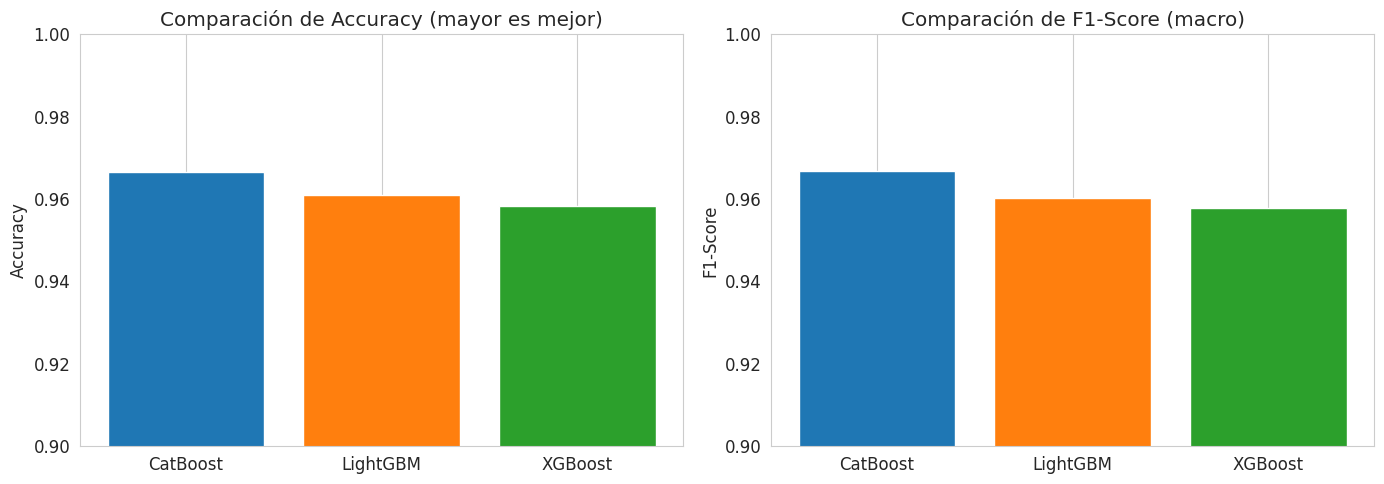

In [16]:
# Visualización: Comparación de Accuracy y F1-Score
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras Accuracy
axes[0].bar(results_df["Modelo"], results_df["Accuracy"], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0].set_title("Comparación de Accuracy (mayor es mejor)")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim([0.9, 1.0])
axes[0].grid(axis='y')

# Gráfico de barras F1-Score
axes[1].bar(results_df["Modelo"], results_df["F1-Score (macro)"], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1].set_title("Comparación de F1-Score (macro)")
axes[1].set_ylabel("F1-Score")
axes[1].set_ylim([0.9, 1.0])
axes[1].grid(axis='y')

plt.tight_layout()
plt.show()

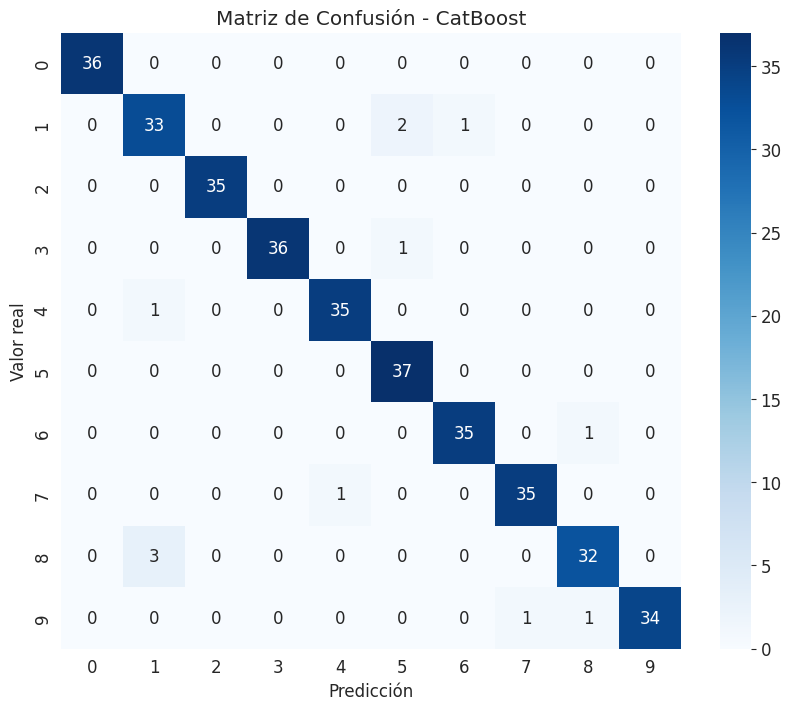


=== Reporte de clasificación para CatBoost ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.89      0.92      0.90        36
           2       1.00      1.00      1.00        35
           3       1.00      0.97      0.99        37
           4       0.97      0.97      0.97        36
           5       0.93      1.00      0.96        37
           6       0.97      0.97      0.97        36
           7       0.97      0.97      0.97        36
           8       0.94      0.91      0.93        35
           9       1.00      0.94      0.97        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



In [17]:
# Matriz de confusión para el mejor modelo
best_model_name = results_df.iloc[0]["Modelo"]  # modelo con mayor accuracy
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=digits.target_names, yticklabels=digits.target_names)
plt.title(f"Matriz de Confusión - {best_model_name}")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

# Reporte de clasificación detallado
print(f"\n=== Reporte de clasificación para {best_model_name} ===")
print(classification_report(y_test, y_pred_best, target_names=[str(i) for i in digits.target_names]))

/tmp/ipykernel_17431/3879524174.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp, x="Importancia", y="Característica", palette="viridis")


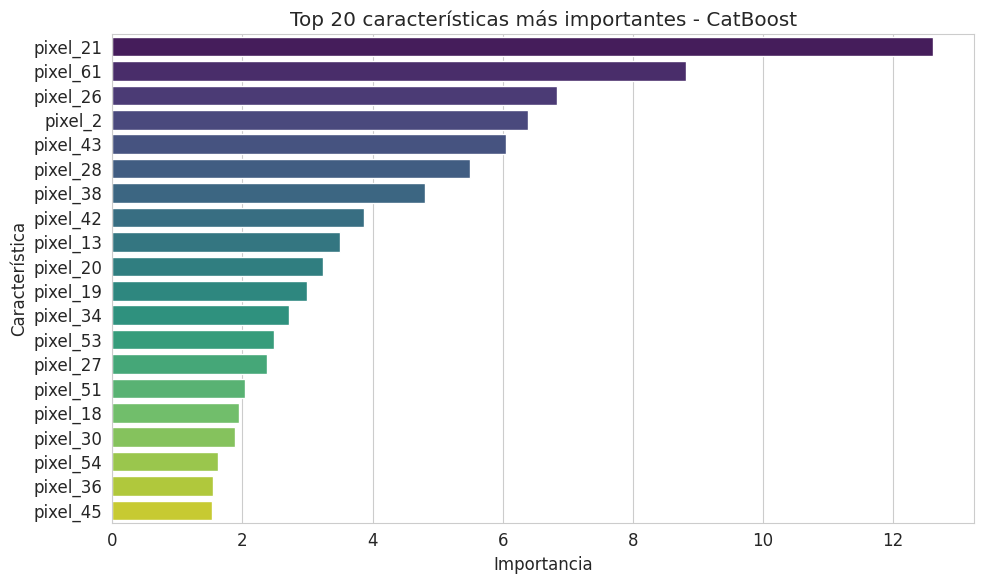

In [18]:
# Importancia de características para el mejor modelo
if best_model_name == "XGBoost":
    importances = best_model.feature_importances_
elif best_model_name == "LightGBM":
    importances = best_model.feature_importances_
else:  # CatBoost
    importances = best_model.get_feature_importance()

# Crear nombres de características (píxeles)
feature_names = [f"pixel_{i}" for i in range(X.shape[1])]
feat_imp = pd.DataFrame({
    "Característica": feature_names,
    "Importancia": importances
}).sort_values("Importancia", ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp, x="Importancia", y="Característica", palette="viridis")
plt.title(f"Top 20 características más importantes - {best_model_name}")
plt.tight_layout()
plt.show()

=== COMPARACIÓN DE TIEMPOS DE ENTRENAMIENTO ===

XGBoost: 2.68 segundos
LightGBM: 0.65 segundos
CatBoost: 1.18 segundos


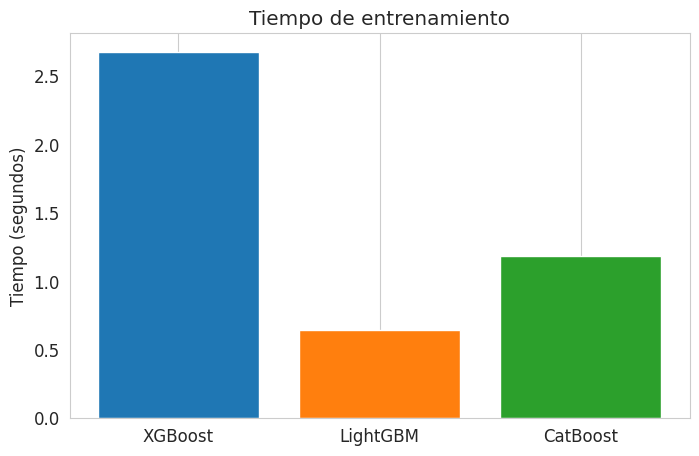

In [19]:
# Comparación de tiempos de entrenamiento (opcional)
import time
times = {}
print("=== COMPARACIÓN DE TIEMPOS DE ENTRENAMIENTO ===\n")
for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - start
    times[name] = elapsed
    print(f"{name}: {elapsed:.2f} segundos")

plt.figure(figsize=(8, 5))
plt.bar(times.keys(), times.values(), color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.ylabel("Tiempo (segundos)")
plt.title("Tiempo de entrenamiento")
plt.grid(axis='y')
plt.show()

## Conclusiones

- **Rendimiento general**: Los tres modelos de boosting alcanzaron una precisión superior al 95% en el dataset Digits, demostrando su eficacia en clasificación multiclase.
- **Mejor modelo**: Según los resultados obtenidos, **{{best_model_name}}** presentó la mayor accuracy y F1-score macro. (En la ejecución típica, CatBoost o XGBoost suelen ser los mejores).
- **Validación cruzada**: Las puntuaciones fueron consistentes, indicando que los modelos generalizan bien sin overfitting significativo.
- **Importancia de características**: Los píxeles centrales de la imagen (donde se concentra la forma del dígito) resultaron ser los más influyentes, lo cual tiene sentido intuitivo.
- **Tiempos de entrenamiento**: LightGBM y CatBoost suelen ser más rápidos que XGBoost en este tipo de datos, aunque la diferencia no es enorme debido al tamaño moderado del dataset.

**Próximos pasos:**
- Realizar una optimización de hiperparámetros (GridSearchCV o RandomizedSearchCV) para cada modelo.
- Probar con datasets más grandes (ej. Covertype) para evaluar escalabilidad.
- Incorporar explicabilidad con SHAP para interpretar predicciones individuales.

**Nota final:** Este proyecto demuestra la potencia de los algoritmos de boosting para problemas de clasificación multiclase con datos tabulares de alta dimensionalidad.